Saved to D:\Phd\php_pulsating_heat_pipe\Krp_Analysis\Advanced_PulseHeatPipe_krp\data\plots\FR60_Q_(A90 B0)_(A60 B0)_(A30 B0)_(A0 B0)\A90_B0\database.csv


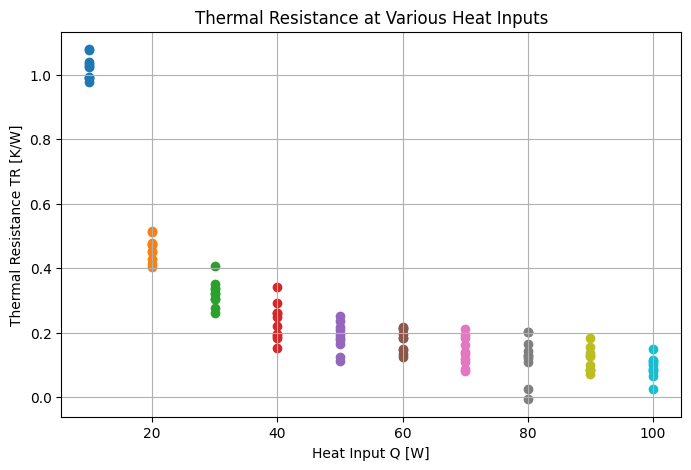

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Example heat input values (Q[W])
Q_values = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# Generate normal distributed TR values for each Q
data = []
for Q in Q_values:
    # Assume mean TR decreases with Q, std is arbitrary
    mean_TR = 1.0 / (Q / 10)  # Example: just for illustration
    std_TR = 0.05
    TR_samples = np.random.normal(loc=mean_TR, scale=std_TR, size=10)
    for tr in TR_samples:
        data.append({'Q[W]': Q, 'TR[K/W]': tr})

df = pd.DataFrame(data)

# Output path
output_dir = r'D:\Phd\php_pulsating_heat_pipe\Krp_Analysis\Advanced_PulseHeatPipe_krp\data\plots\FR60_Q_(A90 B0)_(A60 B0)_(A30 B0)_(A0 B0)\A90_B0'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'database.csv')

# Save to CSV
df.to_csv(output_file, index=False)
print(f"Saved to {output_file}")

# Plot TR at various Q
plt.figure(figsize=(8, 5))
for Q in df['Q[W]'].unique():
    subset = df[df['Q[W]'] == Q]
    plt.scatter([Q]*len(subset), subset['TR[K/W]'], label=f'Q={Q} W')

plt.xlabel('Heat Input Q [W]')
plt.ylabel('Thermal Resistance TR [K/W]')
plt.title('Thermal Resistance at Various Heat Inputs')
plt.grid(True)
plt.show()

In [3]:
# calling database form csv

import pandas as pd
import sys, os
# sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))


db = pd.read_csv('../../data/database/database.csv')
db.head()

,TIME,DATE,TC_1,TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,...,P[bar],Te_mean[K],Tc_mean[K],Te_std[K],Tc_std[K],T_pulse[K],TR[K/W],GFE_Te[KJ/mol],GFE_Tc[KJ/mol],dG[KJ/mol]
0,11:47:22,23/10/2024,32.5,33.2,32.6,32.7,32.8,30.3,30.1,30.2,...,0.36,305.91,302.95,273.42,273.95,0.0,0.07,-2610.15,-2584.89,-25.26
1,11:47:23,23/10/2024,32.7,33.3,32.7,32.7,32.9,30.3,30.1,30.2,...,0.36,306.01,302.95,273.41,273.95,0.0,0.08,-2611.00,-2584.89,-26.11
2,11:47:24,23/10/2024,32.7,33.3,32.7,32.7,32.9,30.4,30.1,30.2,...,0.36,306.01,302.97,273.41,273.98,0.0,0.08,-2611.00,-2585.10,-25.90
3,11:47:26,23/10/2024,32.7,33.3,32.7,32.7,32.9,30.4,30.1,30.2,...,0.36,306.01,302.97,273.41,273.98,0.0,0.08,-2611.00,-2585.10,-25.90
4,11:47:28,23/10/2024,32.7,33.3,32.7,32.7,32.9,30.4,30.1,30.2,...,0.36,306.01,302.97,273.41,273.98,0.0,0.08,-2611.00,-2585.10,-25.90


In [5]:
# filtering the data-on various Q and unique combination of A and B
def filter_data(db, Q=None, A=None, B=None):
    if Q is not None:
        db = db[db['Q[W]'] == Q]
    if A is not None:
        db = db[db['alpha'] == A]
    if B is not None:
        db = db[db['beta'] == B]
    return db
# Example usage
filtered_data = filter_data(db, Q=40, A=90, B=0)
#plotting normal distribution of filtered data
import seaborn as sns  
import matplotlib.pyplot as plt
import numpy as np
filter_data['TR[K/W]'].plot(kind='hist', density=True, bins=30, alpha=0.5, color='g')
plt.title('Normal Distribution of TR[K/W]')

TypeError: 'function' object is not subscriptable

<Axes: ylabel='Frequency'>

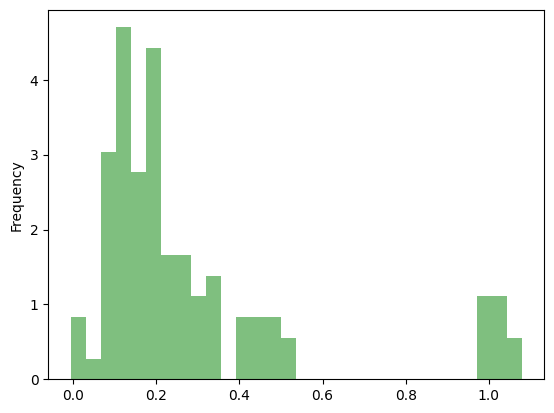

In [7]:
df['TR[K/W]'].plot(kind='hist', density=True, bins=30, alpha=0.5, color='g')